In [11]:
import numpy as np
import proplot as pplt
from matplotlib.lines import Line2D

arr = np.load('/datasets/loads/subregion_mask.npz', allow_pickle=True)['id_to_subregion']
arr[:, 1] = [s.replace('_', ' ') for s in arr[:, 1]]
label_list = arr[:, 1].tolist()
label_list = [s.replace('NorthernGrid', 'NG').replace('WestConnect', 'WC') for s in label_list]

/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() 

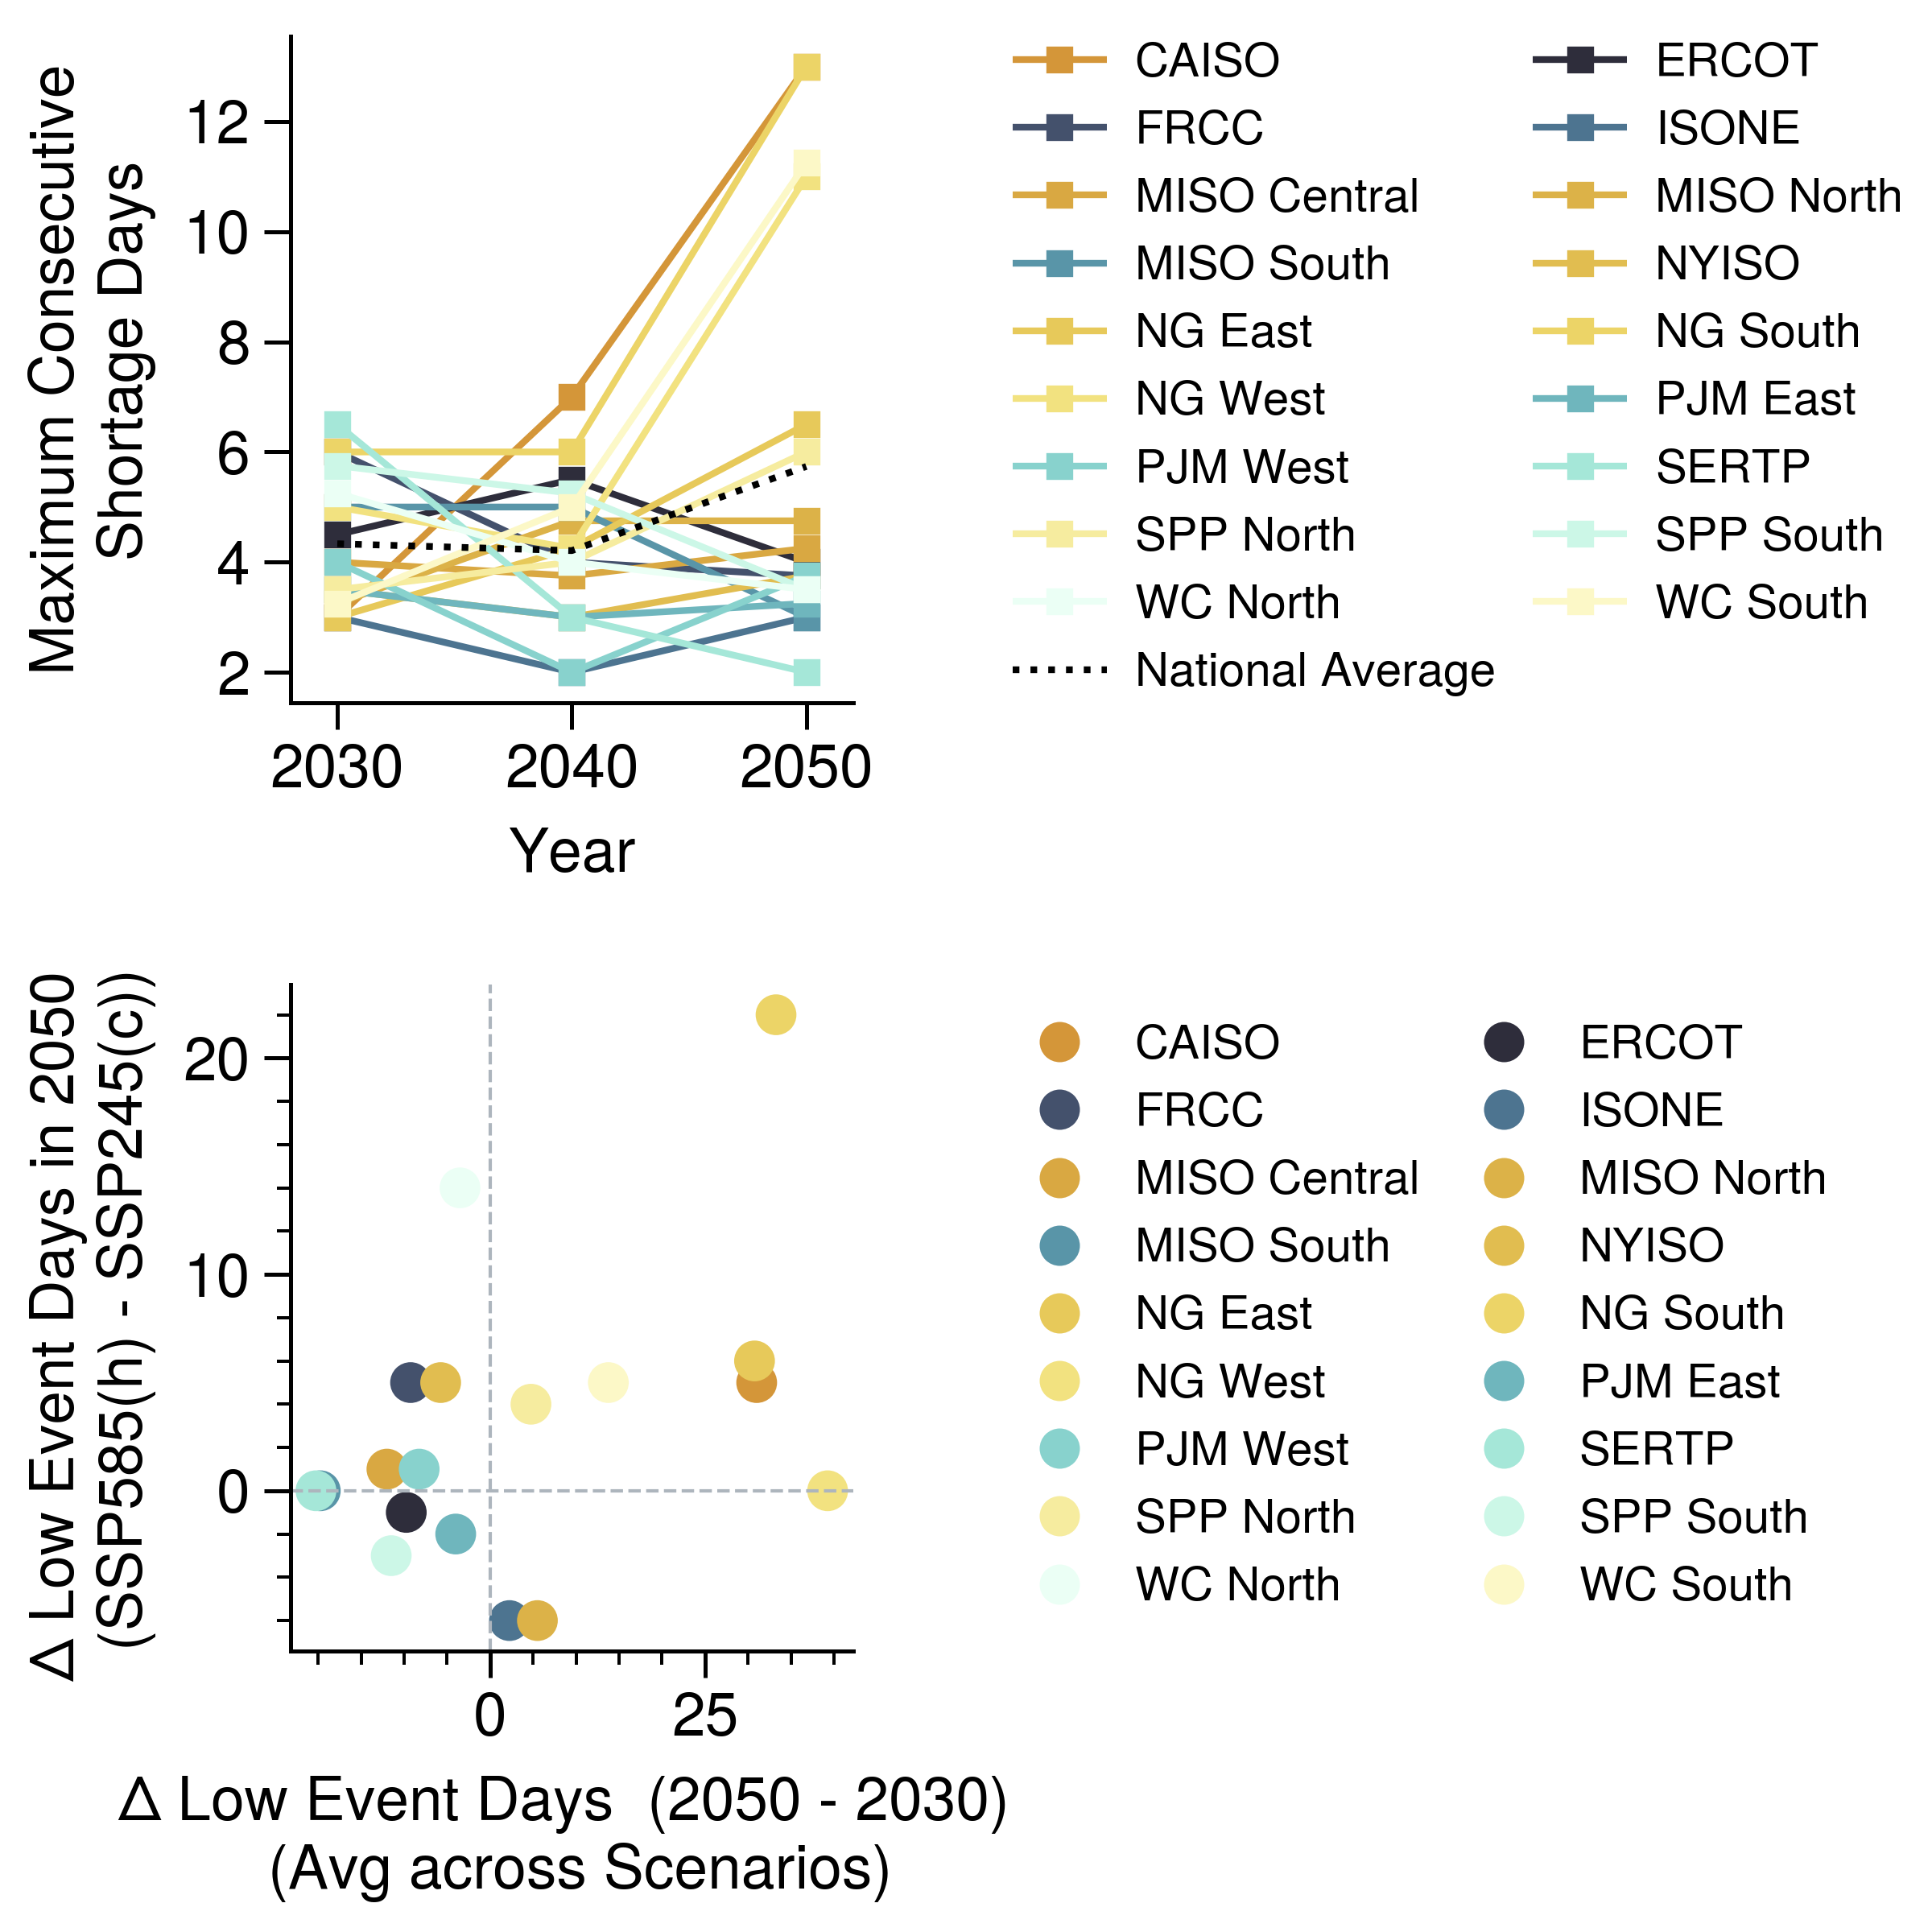

In [12]:
data = np.load('./low_generation_events_summary.npz', allow_pickle=True)
years = [2030, 2040, 2050]
region_ids = list(range(1, 19))
x = np.arange(len(years))
cmap_up = pplt.Colormap('Yellows2_r', N=18)
cmap_down = pplt.Colormap('Blues6_r', N=18)
fig, axs = pplt.subplots(nrows=2, ncols=1, figsize=(4,4),sharey=False, sharex=False, dpi=300)
fig.patch.set_facecolor('white')
ax = axs[0]
legend_handles = []
color_array = []
up_i = 0
down_i = 0
for i, rid in enumerate(region_ids):
    key = str(rid)
    if key not in data:
        continue
    vals = data[key].item()['low_continuous_max']  # shape: (3, n_climate)
    mean_vals = vals.mean(axis=1)  # shape: (3,)
    trend = mean_vals[-1] - mean_vals[0]
    if trend > 0:
       color = cmap_up(up_i)
       up_i = up_i+2
    else:
       color = cmap_down(down_i)
       down_i = down_i+2
    color_array.append(color)
    line = ax.plot(x, mean_vals, marker='s', markersize=3, lw=1, color=color, label=f'Region {rid}')
    legend_handles.append(line[0])
ax.format(xlim=(-0.2, 2.2),xticks=[0,1,2],yticks=[2,4,6,8,10,12],ytickminor=False,xtickminor=False,xticklabels=['2030','2040','2050'],xlabel='Year',
          ylabel='Maximum Consecutive\n Shortage Days', grid=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

all_mean_vals = []
for rid in region_ids:
    key = str(rid)
    if key not in data:
        continue
    vals = data[key].item()['low_continuous_max']  # shape: (3, n_climate)
    mean_vals = vals.mean(axis=1)  # shape: (3,)
    all_mean_vals.append(mean_vals)

avg_vals = np.mean(np.stack(all_mean_vals, axis=0), axis=0)

national_line = ax.plot(x, avg_vals, color='black', lw=1.0, linestyle=':', label='National Avg.')
legend_handles.append(national_line[0])
label_list.append('National Average')
ax.legend(legend_handles, label_list, ncol=2, loc='right', frame=False, prop={'size': 7}, handlelength=2.0,
    handletextpad=0.6, columnspacing=0.8, borderaxespad=0.3)
data = np.load('./low_generation_events_summary.npz', allow_pickle=True)
region_ids = list(range(1, 19))

x_vals = []  
y_vals = []  
labels = [] 
sizes = []
for rid in region_ids:
    key = str(rid)
    if key not in data:
        continue
    low_event = data[key].item()['low_event_total']  # shape: (3, n_climate)
    delta_years = low_event[2].mean() - low_event[0].mean()
    delta_scenario = low_event[2][3] - low_event[2][0]
    mean_2030 = low_event[0].mean()
    mean_2050 = low_event[2].mean()
    delta_percent = (mean_2050 - mean_2030) / (mean_2030 + 1e-6)  
    sizes.append(delta_percent)
    x_vals.append(delta_years)
    y_vals.append(delta_scenario)
    labels.append(f'Region {rid}')

ax = axs[1]
ax.axhline(0, color='gray5', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray5', linestyle='--', linewidth=0.5)
sc = ax.scatter(x_vals, y_vals, color=color_array, s=30)
ax.format(
    xlabel='Δ Low Event Days  (2050 - 2030) \n (Avg across Scenarios)',
    ylabel='Δ Low Event Days in 2050 \n (SSP585(h) - SSP245(c))', grid=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
           markeredgecolor='none', markersize=6, label=label)
    for c, label in zip(color_array, label_list)]

ax.legend(
    legend_handles, label_list, ncol=2, loc='right',
    frame=False, prop={'size': 7}, handlelength=2.0,        
    handletextpad=0.6, columnspacing=0.8, borderaxespad=0.3)
fig.savefig("./figs/solar_daily_trend.png", bbox_inches='tight', pad_inches=0)